# Feature Enginnering - Tratamento de Outliers: Goodreads Dataset

Nesta etapa, fazemos a transição oficial do diagnóstico visual (EDA) para a engenharia de dados. Com base nas análises anteriores, já sabemos que os valores extremos do nosso dataset se dividem em dois comportamentos distintos:

* **Os Fenômenos (Outliers de Negócio):** Obras de altíssimo impacto (Best-sellers) que puxam as métricas de `total_votes` para a extrema direita.

### Roteiro de Ação:
1. **Validação Estatística (Quick Look):** Aplicaremos o cálculo do IQR (Intervalo Interquartil) para confirmar matematicamente as fronteiras que observamos na exploração visual.
2. **Tratamento Definitivo (Cirurgia):** 
   * Preservaremos os fenômenos de mercado criando *flags* categóricas (Feature Engineering, ex: `is_bestseller`), garantindo que a genialidade da obra não seja deletada nem envieze modelos futuros.

In [2]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb
import src.utils.features as feat

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Carregando Dados

In [3]:
caminho = '../../data/interim/books/goodreads_books_enriched.parquet'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (10897, 18)


In [4]:
caminho = '../../data/interim/books/goodreads_books_exploded.parquet'
df_books_genres = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (94023, 18)


---
## Análise de Outliers 

In [5]:
dict_total_votes = {
    'cerca': None,
    'df_outliers': None
}

dict_total_votes['cerca'], dict_total_votes['df_outliers'] = mt.calcular_metricas_outliers(
    df_books, 'total_votes'
)

Primeiro Quartil (Q1): 118.00
Terceiro Quartil (Q3): 5,221.00
Limite Estatístico (Cerca Superior): 12,875.50
Total de Outliers Detectados: 1671 de 10897 (15.33%)


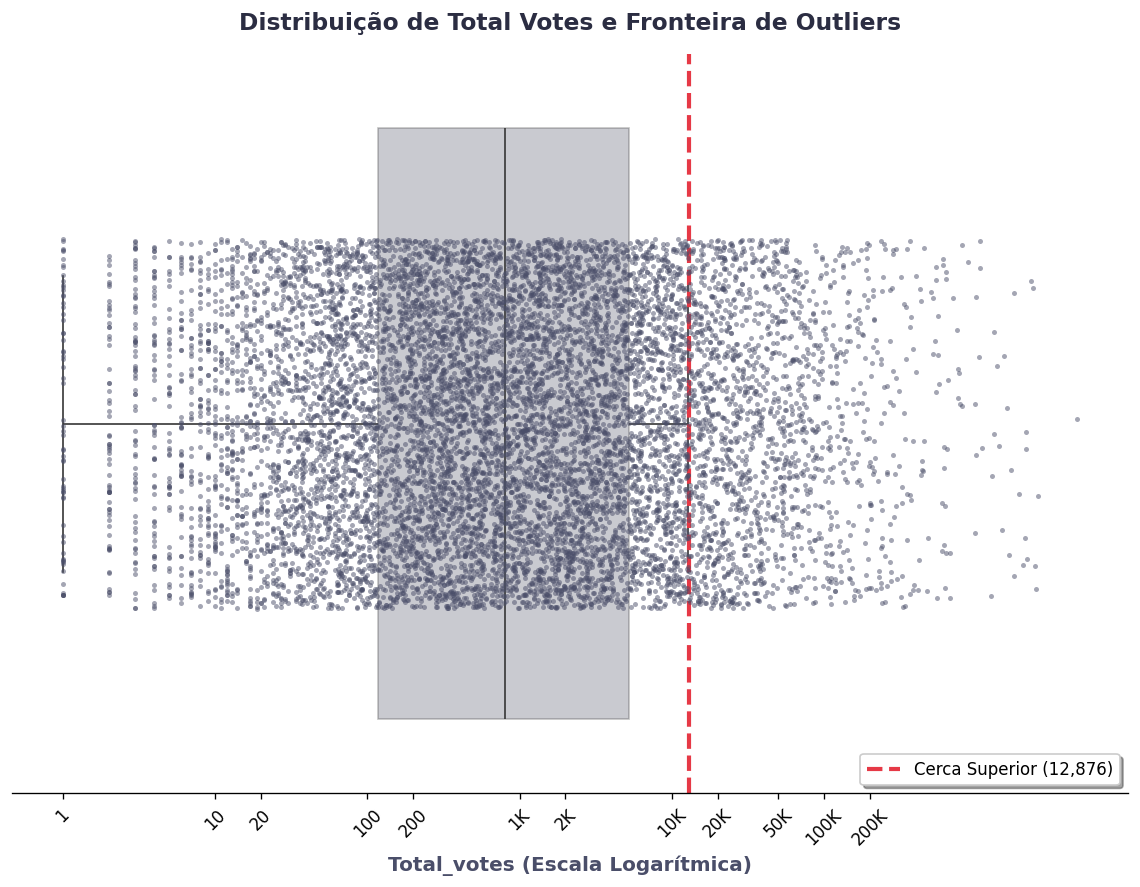

In [6]:
graf.grafico_fronteira_outliers(
    df_plot=df_books,
    coluna='total_votes',
    cerca_superior=dict_total_votes['cerca'],
    usar_log=True,
    tipo_dado='contagem_centena_milhar'
)

In [7]:
display(tb.estilizar_tabela(
    df=dict_total_votes['df_outliers']
        .sort_values(
            by='total_votes', 
            ascending=False
        ),
    qtd_linhas=5,
    colunas_selecionadas=['title', 'total_votes', 'popularity_tier'],
    caption="Top 5 Títulos que puxam a cauda para a direita:"
))

,title,total_votes,popularity_tier
10124,Twilight (Twilight #1),"4,597,666",Mass Appeal
1669,The Hobbit or There and Back Again,"2,530,894",Mainstream Hit
1437,The Catcher in the Rye,"2,457,092",Mass Appeal
301,Angels & Demons (Robert Langdon #1),"2,418,736",Mass Appeal
3,Harry Potter and the Prisoner of Azkaban (Harry Potter #3),"2,339,585",Mainstream Hit


In [8]:
dict_num_pages = {
    'cerca': None,
    'df_outliers': None
}

dict_num_pages['cerca'], dict_num_pages['df_outliers'] = mt.calcular_metricas_outliers(
    df_books, 'num_pages'
)

Primeiro Quartil (Q1): 198.00
Terceiro Quartil (Q3): 416.00
Limite Estatístico (Cerca Superior): 743.00
Total de Outliers Detectados: 566 de 10897 (5.19%)


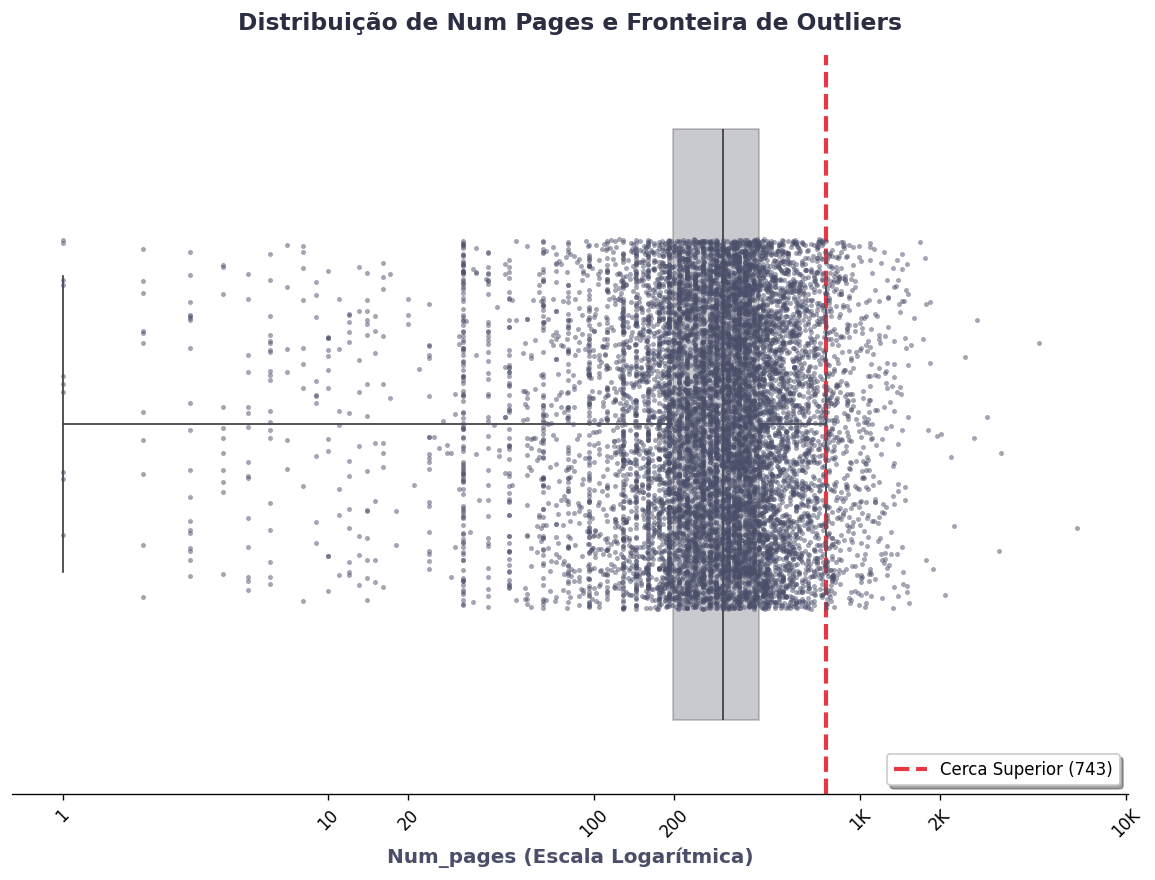

In [9]:
graf.grafico_fronteira_outliers(
    df_plot=df_books,
    coluna='num_pages',
    cerca_superior=dict_num_pages['cerca'],
    usar_log=True,
    tipo_dado='contagem_centena_milhar'
)

In [10]:
display(tb.estilizar_tabela(
    df=dict_num_pages['df_outliers']
        .sort_values(
            by='num_pages', 
            ascending=False
        ),
    qtd_linhas=10,
    colunas_selecionadas=['title', 'num_pages', 'popularity_tier'],
    caption="Top 10 Títulos mais longos:"
))

,title,num_pages,popularity_tier
6373,The Complete Aubrey/Maturin Novels (5 Volumes),"6,576 págs",Mainstream Hit
6674,The Second World War,"4,736 págs",Mainstream Hit
10687,Remembrance of Things Past (Boxed Set),"3,400 págs",Hidden Gem / Cult
6,Harry Potter Collection (Harry Potter #1-6),"3,342 págs",Mainstream Hit
6692,Summa Theologica 5 Vols,"3,020 págs",Mainstream Hit
7709,Harrison's Principles of Internal Medicine,"2,751 págs",Hidden Gem / Cult
4,Harry Potter Boxed Set Books 1-5 (Harry Potter #1-5),"2,690 págs",Mainstream Hit
10532,The Sword of Truth Boxed Set I: Wizard's First Rule Blood of the Fold Stone of Tears (Sword of Truth #1-3),"2,480 págs",Mainstream Hit
6136,The J.R.R. Tolkien Companion and Guide,"2,264 págs",Hidden Gem / Cult
5519,Study Bible: NIV,"2,198 págs",Mainstream Hit


---
## Feature Engineering

In [16]:
# Criando a flag no dataset principal e fazendo o merge com df_books_genres
feat.adicionar_nova_tag(
    df=df_books,
    coluna='total_votes',
    id='book_id',
    cerca_superior=dict_total_votes['cerca'],
    dfs_exploded=[df_books_genres]
)

In [17]:
# Verificando o sucesso da operação
print("Distribuição da nova Feature 'is_elite_engagement':")
print(df_books['is_elite_engagement'].value_counts())

print("\nProporção:")
print(
    (df_books['is_elite_engagement']
        .value_counts(normalize=True) * 
        100
    ).apply(
        lambda x: f"{x:.2f}%"
    ) 
)

# Verificando o resultado no explodido
print("\n"+"="*50)
print("Verificação da Flag no Dataset Explodido:")
print(df_books_genres['is_elite_engagement'].value_counts())

print("\nProporção:")
print(
    (df_books_genres['is_elite_engagement']
        .value_counts(normalize=True) * 
        100
    ).apply(
        lambda x: f"{x:.2f}%"
    ) 
)

Distribuição da nova Feature 'is_elite_engagement':
is_elite_engagement
False    9226
True     1671
Name: count, dtype: int64

Proporção:
is_elite_engagement
False    84.67%
True     15.33%
Name: proportion, dtype: object

Verificação da Flag no Dataset Explodido:
is_elite_engagement
False    77313
True     16710
Name: count, dtype: int64

Proporção:
is_elite_engagement
False    82.23%
True     17.77%
Name: proportion, dtype: object


---
## Salvando Datasets

In [18]:
# Salvando DataFrame 
ds.save_dataset(
    df=df_books,
    pasta='../../data/processed/books',
    nome_arquivo='goodreads_books_master', 
    tipo_arquivo='parquet'
)

# Salvando DataFrame explodido para uso futuro
ds.save_dataset(
    df=df_books_genres,
    pasta='../../data/processed/books',
    nome_arquivo='goodreads_books_genres_master', 
    tipo_arquivo='parquet'
)

Sucesso! Ficheiro guardado em '..\data\processed\books\goodreads_books_master.parquet'
Sucesso! Ficheiro guardado em '..\data\processed\books\goodreads_books_genres_master.parquet'


## Conclusão

Conforme o roteiro estabelecido no início da análise, as seguintes ações foram executadas com sucesso:

* **Feature Engineering Consolidada:** Aplicamos o cálculo do IQR na coluna `total_votes` e criamos a flag `is_bestseller`, preservando os fenômenos de mercado no dataset principal sem perda de dados.
  
* **Propagação Estrutural:** Transferimos a inteligência da nova flag para o dataset explodido de gêneros via *merge*, garantindo que as análises futuras por categoria sejam precisas e não enviesem a matemática.
  
* **Auditoria de Integridade:** Inspecionamos os limites superiores de `num_pages` e validamos que os valores extremos correspondem a coleções reais (*Box Sets*) e enciclopédias, dispensando exclusões.

* **Persistência:** Os datasets finalizados (`goodreads_books_master.parquet` e `goodreads_books_genres_master.parquet`) foram exportados para o diretório `data/processed/`.